In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the raw CSV file again to ensure we start from scratch with the new logic
raw_reliance_df = pd.read_csv('/content/MRF_5yr_data.csv')

# Clean the DataFrame:
# 1. Skip the first two rows (metadata)
# 2. Rename the 'Price' column to 'Date'
cleaned_df_for_ohclv = raw_reliance_df.iloc[2:].copy()
cleaned_df_for_ohclv = cleaned_df_for_ohclv.rename(columns={'Price': 'Date'})

# Convert the 'Date' column to datetime and set as index
cleaned_df_for_ohclv['Date'] = pd.to_datetime(cleaned_df_for_ohclv['Date'], format='%Y-%m-%d')
cleaned_df_for_ohclv.set_index('Date', inplace=True)

# Convert OHLCV columns to numeric, coercing errors to NaN
ohclv_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in ohclv_cols:
    cleaned_df_for_ohclv[col] = pd.to_numeric(cleaned_df_for_ohclv[col], errors='coerce')

# Define aggregation dictionary for monthly resampling
# 'ME' for month end frequency
monthly_ohclv_df = cleaned_df_for_ohclv.resample('ME').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
})

# Display the first few rows of the new monthly OHCLV DataFrame
print("\nMonthly OHCLV MRF Data:")
display(monthly_ohclv_df.head())


Monthly OHCLV MRF Data:


,Open,High,Low,Close,Volume
Date,,,,,
2021-05-31,77641.067109,83258.409609,75310.836632,82937.531250,231920
2021-06-30,82939.514457,86565.339267,78858.500671,79405.601562,340341
2021-07-31,79425.923186,82747.742264,78534.542136,79235.007812,190621
2021-08-31,79821.561092,82115.093014,75444.939193,79212.484375,277835
2021-09-30,79468.010918,82646.734450,77530.988787,78847.718750,267200


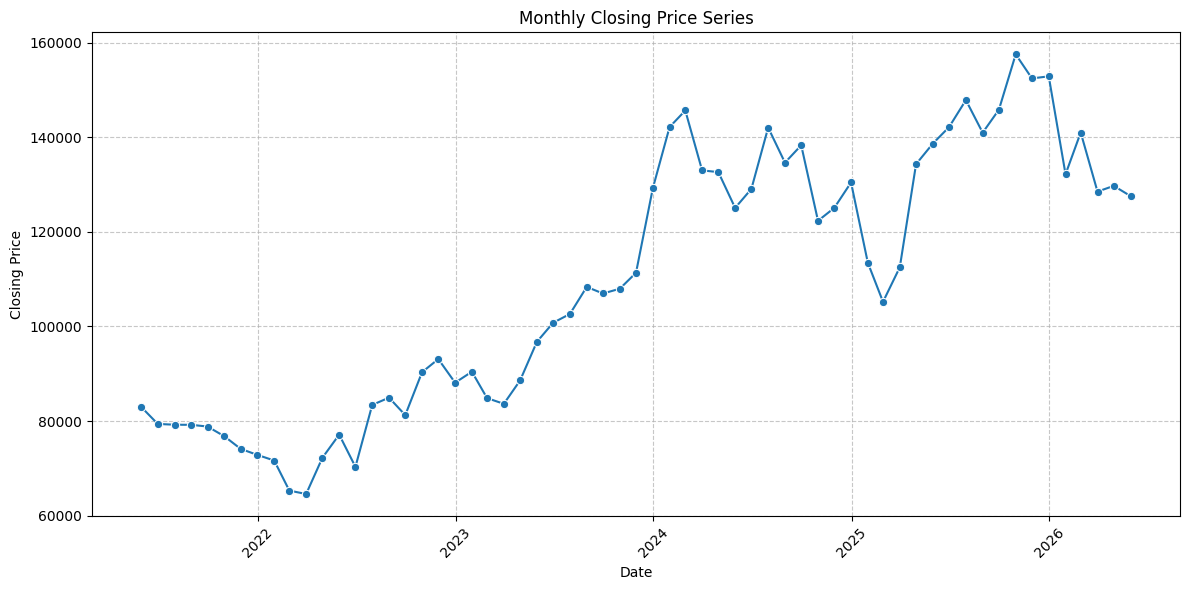

In [ ]:
# Create the price series line chart for monthly data
plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_ohclv_df.index, y='Close', data=monthly_ohclv_df, marker='o', linestyle='-')
plt.title('Monthly Closing Price Series')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Plot histogram of monthly returns
plt.figure(figsize=(10, 6))
sns.histplot(monthly_ohclv_df['Monthly_Return'].dropna(), kde=True, bins=20)
plt.title('Distribution of Monthly Returns')
plt.xlabel('Monthly Return (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

KeyError: 'Monthly_Return'

<Figure size 1000x600 with 0 Axes>

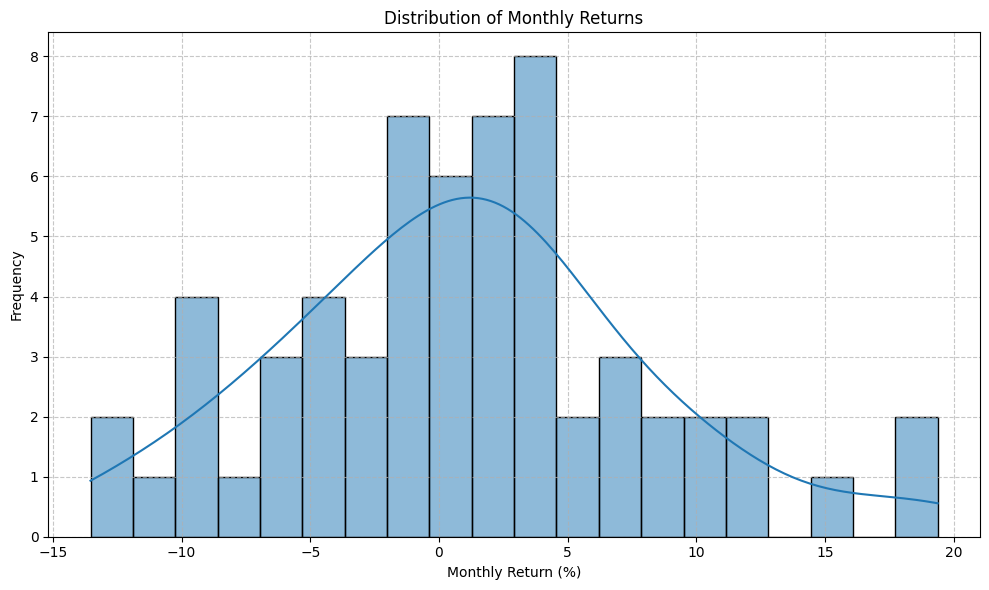

In [ ]:
# Calculate monthly returns
monthly_ohclv_df['Monthly_Return'] = monthly_ohclv_df['Close'].pct_change() * 100

# Plot histogram of monthly returns
plt.figure(figsize=(10, 6))
sns.histplot(monthly_ohclv_df['Monthly_Return'].dropna(), kde=True, bins=20)
plt.title('Distribution of Monthly Returns')
plt.xlabel('Monthly Return (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Install mplfinance library for candlestick charts
!pip install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.9 MB/s eta 0:00:00


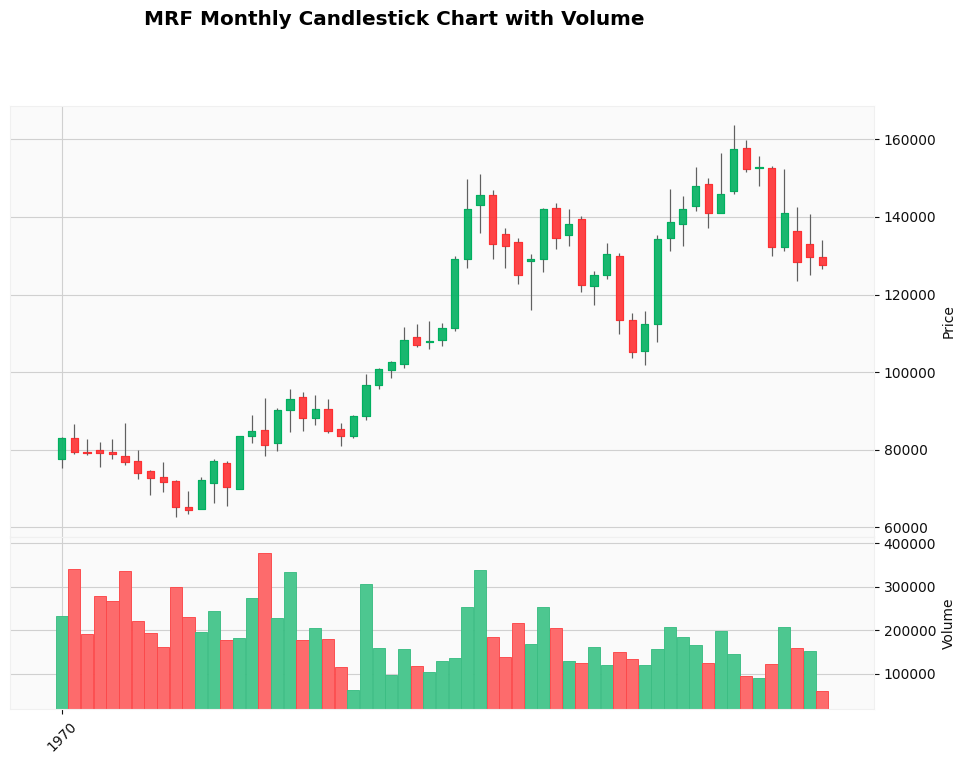

In [ ]:
import mplfinance as mpf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker # Import matplotlib.ticker for AutoMinorLocator

# Ensure the DataFrame index is a DatetimeIndex
# monthly_ohclv_df already has 'Date' as index which is a DatetimeIndex

# Create the candlestick chart with volume, returning the figure and axes list
fig, axlist = mpf.plot(monthly_ohclv_df,
                       type='candle',
                       style='yahoo',
                       title='MRF Monthly Candlestick Chart with Volume',
                       ylabel='Price',
                       ylabel_lower='Volume',
                       figscale=1.5, # Adjust figure size
                       volume=True, # Add volume subplot
                       returnfig=True
                      )

# Access the main price axis (usually the first one in axlist for a single panel plot with volume)
ax_price = axlist[0]

# Set major locator to place ticks at the start of each year
ax_price.xaxis.set_major_locator(mdates.YearLocator())
# Set major formatter to display only the year
ax_price.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Optionally, remove minor ticks if they are distracting
ax_price.xaxis.set_minor_locator(ticker.AutoMinorLocator(n=0)) # Corrected: use ticker.AutoMinorLocator

# Auto-format date labels to prevent overlap
fig.autofmt_xdate()

plt.show()

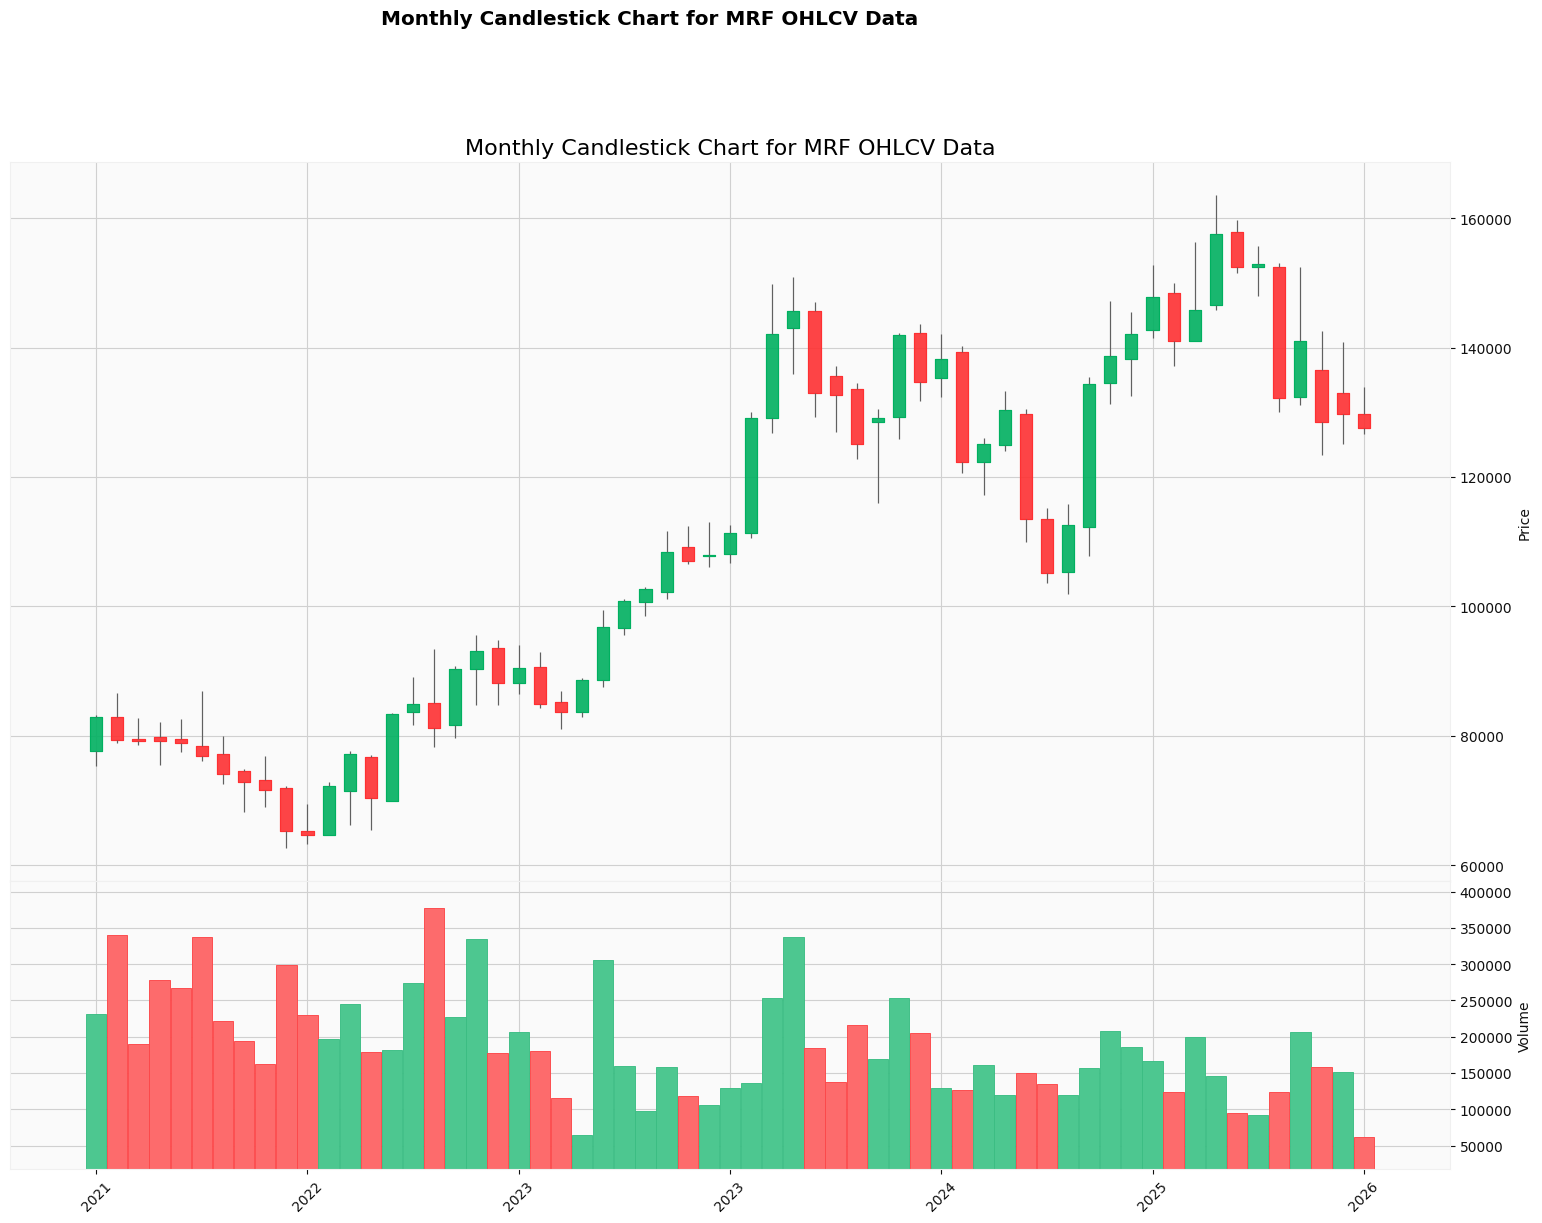

In [ ]:
import matplotlib.ticker as mticker

# Ensure the index is a DatetimeIndex for mplfinance
monthly_ohclv_df.index = pd.to_datetime(monthly_ohclv_df.index)

# Create the candlestick chart with the volume subplot
fig, axlist = mpf.plot(monthly_ohclv_df,
                       type='candle',
                       style='yahoo',
                       title='Monthly Candlestick Chart for MRF OHLCV Data',
                       ylabel='Price',
                       # Removed ylabel_lower from here to prevent mplfinance from appending '10^6'
                       volume=True, # Set volume to True to include the volume subplot
                       returnfig=True,
                       figscale=2.5, # Increased figscale for better x-axis label visibility
                       datetime_format='%Y') # Display only the year on the x-axis

# Customize title for better readability
axlist[0].set_title('Monthly Candlestick Chart for MRF OHLCV Data', fontsize=16)

# Get the volume axis (usually axlist[2] for candlestick charts with volume)
volume_ax = axlist[-1] # Assuming volume axis is the last one

# Define a formatter function for crores
def crores_formatter(x, pos):
    return f'{x / 10_000_000:.1f} Cr' # Divide by 1 Crore (10^7) and format with 1 decimal place

# Apply the formatter to the volume axis's y-ticks
volume_ax.yaxis.set_major_formatter(mticker.FuncFormatter(crores_formatter))

# Explicitly set the y-label for the volume axis after applying the formatter
volume_ax.set_ylabel('Volume (Crores)')

# Show the plot
plt.show()